# Notebook 2 — Boötes III stream model and Figure 5

This notebook generates **Figure 5** of the paper: a 5-row x 4-column grid
showing the predicted Boo III tidal stream in five observables
(Dec, $\mu_\alpha\cos\delta$, $\mu_\delta$, RV, distance modulus) for four
variation groups (Fiducial; MW mass scan; LMC mass scan; $V_\phi$ scan).

**Pipeline**
1. Load the GMM systemic samples from notebook 1 to get the Boo III 6-D
   phase-space mean + 1$\sigma$ uncertainties.
2. Compute the progenitor mass from the Wolf+10 estimator using the GMM
   $\sigma_v$ and the Boo III azimuthal half-light radius.
3. For each of 9 variations, build the McMillan17 + LMC potential, sample
   1000 leading + 1000 trailing spray particles via
   `galpy.df.fardal15spraydf`, and cache the result as a pkl with a fixed
   random seed (so any run is bit-reproducible).
4. Run `streamTrack(sf=4)` on each cached spray and render the per-
   variation 1$\times$5 inspection plot inline.
5. Assemble the final 5$\times$4 master grid and save to
   `figures/fig5_streamtrack_grid.pdf`.

This notebook is **standalone** and uses **astropy v4.0 solar motion**
[$U_{\rm pec}, V_{\rm pec}, W_{\rm pec}$] = [$-12.9, +12.5, +7.78$] km/s
throughout (matches notebook 1).


## 0 · Setup — paths, imports, environment

In [1]:
# Force OMP to single-thread to avoid GIL contention with our
# Python-callback NIP / MovingObjectPotential — see the bench in the
# parallelisation discussion. We parallelise instead at the *process*
# level, two workers, via multiprocess below.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"]      = "1"

import sys, time, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import units as u


from galpy.orbit import Orbit
from galpy.df import fardal15spraydf
from galpy.util import galpyWarning
from galpy.util.conversion import get_physical
from galpy.potential import (
    ChandrasekharDynamicalFrictionForce, HernquistPotential,
    MovingObjectPotential, NonInertialFrameForce,
    evaluateRforces, evaluatephitorques, evaluatezforces,
)
from galpy.potential.mwpotentials import McMillan17 as _McMillan17_base

warnings.filterwarnings("ignore", category=galpyWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ---- Project paths ----
NB_DIR    = Path.cwd().resolve()
PROJ      = NB_DIR.parent
DATA_DIR  = PROJ / "data"
OUT_DIR   = PROJ / "output"
FIG_DIR   = PROJ / "figures"
CACHE_DIR = OUT_DIR / "spray_cache_new6D"
for d in (OUT_DIR, FIG_DIR, CACHE_DIR):
    d.mkdir(exist_ok=True)

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.labelsize": 14, "axes.titlesize": 15, "axes.linewidth": 1.2,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.fontsize": 11, "legend.frameon": False,
    "xtick.labelsize": 13, "ytick.labelsize": 13,
    "font.family": "serif", "mathtext.fontset": "cm",
})

print(f"Project root  : {PROJ}")
print(f"Spray cache   : {CACHE_DIR}")
print(f"OMP threads   : {os.environ['OMP_NUM_THREADS']}")


Project root  : /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim
Spray cache   : /Users/tingli/Dropbox/claude_research/boo3paper/paper_final_new6D_newSim/output/spray_cache_new6D
OMP threads   : 1


## 1 · Boötes III geometry + GMM systemic values

Pulled from the notebook 1 outputs (`output/boo3_gmm_samples.h5`).


In [2]:
# Boo III geometry — NEW 6D ellipse-centroid + Garofalo+22 RRL distance
RA_BOO3   = 209.5567
DEC_BOO3  = 26.5529
DIST_KPC  = 48.47
DM_BOO3   = 5 * np.log10(DIST_KPC * 1000 / 10.0)
RHALF_CIRC_AM  = 33.03
RHALF_CIRC_DEG = RHALF_CIRC_AM / 60.0
RHALF_CIRC_KPC = DIST_KPC * np.tan(np.radians(RHALF_CIRC_DEG))
assert abs(RA_BOO3 - 209.5567) < 1e-3 and abs(DEC_BOO3 - 26.5529) < 1e-3, \
    "Must use NEW ellipse-centroid (209.5567, 26.5529)"
print(f"R_h (azimuthal): {RHALF_CIRC_AM:.2f}' = {RHALF_CIRC_KPC*1000:.1f} pc = {RHALF_CIRC_KPC:.4f} kpc")

# Pull GMM medians from the canonical samples file written by 01_compute_gmm.py
samples = pd.read_hdf(OUT_DIR / "boo3_gmm_samples.h5", key="samples")
vhel_med, vhel_err   = float(samples["vhel_0"].median()),  float(samples["vhel_0"].std())
pmra_med, pmra_err   = float(samples["pmr_0"].median()),   float(samples["pmr_0"].std())
pmdec_med, pmdec_err = float(samples["pmd_0"].median()),   float(samples["pmd_0"].std())
sig_v_med            = float(np.median(10 ** samples["log_sig_vhel"].values))
print(f"systemic centre:  v_hel = {vhel_med:+.3f} +/- {vhel_err:.3f} km/s")
print(f"                  pmra  = {pmra_med:+.4f} +/- {pmra_err:.4f} mas/yr")
print(f"                  pmdec = {pmdec_med:+.4f} +/- {pmdec_err:.4f} mas/yr")
print(f"                  sigma_v (median) = {sig_v_med:.3f} km/s")
# Both old and new centre markers for the spatial Fig 5 panel.
# RA_BOO3/DEC_BOO3 above are the NEW ellipse-centroid (this work);
# RA_OLD_BOO3/DEC_OLD_BOO3 are the Grillmair+09 literature centre,
# overlaid for direct comparison in the Fig 5 top-left panel only.
RA_NEW_BOO3, DEC_NEW_BOO3 = RA_BOO3, DEC_BOO3
RA_OLD_BOO3, DEC_OLD_BOO3 = 209.30, 26.80


R_h (azimuthal): 33.03' = 465.7 pc = 0.4657 kpc
systemic centre:  v_hel = +191.216 +/- 0.847 km/s
                  pmra  = -1.1625 +/- 0.0181 mas/yr
                  pmdec = -0.8827 +/- 0.0134 mas/yr
                  sigma_v (median) = 1.694 km/s


## 2 · Progenitor mass — Wolf+10 estimator

$$
M_{1/2} = \frac{4\,\sigma_v^2\,R_h}{G},
$$

evaluated with the Boötes III azimuthal $R_h = 33.03'$ and the GMM-fit
$\sigma_v$ (from notebook 1).


In [3]:
G_KPC_KMS_MSUN = 4.30091e-6   # G in (km/s)^2 kpc / Msun
PROG_MASS = 4.0 * sig_v_med**2 * RHALF_CIRC_KPC / G_KPC_KMS_MSUN
print(f"PROG_MASS  =  4 * sigma_v^2 * R_h_circ / G")
print(f"           =  4 * {sig_v_med:.3f}^2 * {RHALF_CIRC_KPC:.4f} / {G_KPC_KMS_MSUN:.3e}")
print(f"           =  {PROG_MASS:.3e} M_sun")


PROG_MASS  =  4 * sigma_v^2 * R_h_circ / G
           =  4 * 1.694^2 * 0.4657 / 4.301e-06
           =  1.243e+06 M_sun


## 3 · Run parameters

| parameter | value | notes |
|:--|:--|:--|
| `N_PER_ARM`        | 1000   | leading + trailing arm |
| `TDISRUPT`         | 3 Gyr  | tidal disruption baseline |
| `N_STEP`           | 10001  | leapfrog integration steps per orbit |
| `TRACK_N_DENSE`    | 1001   | output spline density (visual only) |
| `TRACK_TIME_RANGE` | 3 Gyr  | streamTrack time window |
| `SMOOTHING_FACTOR` | 4.0    | default sf for streamTrack |
| `SOLAR_MOTION`     | $[-12.9, +12.5, +7.78]$ km/s | astropy v4.0, identical to notebook 1 |


In [4]:
SOLAR_MOTION_FID = [-12.9, 12.5, 7.78]
N_PER_ARM        = 1000
TDISRUPT         = 3.0
N_STEP           = 10001
TRACK_N_DENSE    = 1001
TRACK_TIME_RANGE = 3.0
SMOOTHING_FACTOR = 4.0       # default; can be re-rendered later at any sf

# 6-D phase-space mean + 1-sigma scatter for the spray progenitor.
PARAMS_6D = [RA_BOO3, DEC_BOO3, DIST_KPC, pmra_med, pmdec_med, vhel_med]


def dm(d_kpc):
    return 5.0 * np.log10(d_kpc * 1e3 / 10.0)


## 4 · Variation table (9 variations)

Same as `final_code/08b_fig5_streamtrack_grid.py`.

| key | label | mw_factor | lmc_factor | solar_motion | use_lmc |
|:--|:--|--:|--:|:--|:--:|
| `fid`   | Fiducial      | 1.0  | 1.0  | $[-12.9, +12.5, +7.78]$ | yes |
| `lmc2`  | LMC mass x2   | 1.0  | 2.0  | "" | yes |
| `lmc05` | LMC mass x0.5 | 1.0  | 0.5  | "" | yes |
| `mw15`  | MW mass x1.5  | 1.5  | 1.0  | "" | yes |
| `mw2`   | MW mass x2    | 2.0  | 1.0  | "" | yes |
| `mw05`  | MW mass x0.5  | 0.5  | 1.0  | "" | yes |
| `vp233` | $V_\phi=233$  | 1.0  | 1.0  | $[-12.9,  0.0, +7.78]$ | yes |
| `vp258` | $V_\phi=258$  | 1.0  | 1.0  | $[-12.9, 25.0, +7.78]$ | yes |
| `nolmc` | No LMC        | 1.0  | 1.0  | $[-12.9, +12.5, +7.78]$ | no  |

Master grid columns (4 groups):

| col | name | variations stacked in this column |
|:--|:--|:--|
| 1 | Fiducial | `fid` |
| 2 | MW mass | `mw05, fid, mw15, mw2` |
| 3 | LMC mass | `nolmc, lmc05, fid, lmc2` |
| 4 | $V_\phi$ | `vp233, fid, vp258` |


In [5]:
VARIATIONS = [
    # key,  label,             color,             mw_factor, lmc_factor, solar_motion,             use_lmc
    ("fid",   "Fiducial",        "deepskyblue",     1.0,  1.0,  SOLAR_MOTION_FID,           True),
    ("lmc2",  "LMC mass x2",     "salmon",          1.0,  2.0,  SOLAR_MOTION_FID,           True),
    ("lmc05", "LMC mass x0.5",   "pink",            1.0,  0.5,  SOLAR_MOTION_FID,           True),
    ("mw15",  "MW mass x1.5",    "orchid",          1.5,  1.0,  SOLAR_MOTION_FID,           True),
    ("mw2",   "MW mass x2",      "purple",          2.0,  1.0,  SOLAR_MOTION_FID,           True),
    ("mw05",  "MW mass x0.5",    "magenta",         0.5,  1.0,  SOLAR_MOTION_FID,           True),
    ("vp233", "Vphi = 233",      "gold",            1.0,  1.0,  [-12.9,  0.0,  7.78],       True),
    ("vp258", "Vphi = 258",      "brown",           1.0,  1.0,  [-12.9, 25.0,  7.78],       True),
    ("nolmc", "No LMC",          "cornflowerblue",  1.0,  1.0,  SOLAR_MOTION_FID,           False),
]
VARIATION_BY_KEY = {v[0]: v for v in VARIATIONS}

GROUPS = [
    ("Fiducial",     ["fid"]),
    ("MW mass",      ["mw05", "fid", "mw15", "mw2"]),
    ("LMC mass",     ["nolmc", "lmc05", "fid", "lmc2"]),
    (r"$V_\phi$",    ["vp233", "fid", "vp258"]),
]


## 5 · Helpers — build LMC potential, sample spray, run streamTrack

The spray sampling is the expensive step (~16 min per variation at
`OMP_NUM_THREADS=1`). We pickle each spray result in
`output/spray_cache_new6D/spray_{key}.pkl` so subsequent runs (and re-renders
at different `sf`) reload from disk in a fraction of a second.

The cache filename uniquely encodes (key, n_per_arm, tdisrupt, prog_mass,
solar_motion, mw_factor, lmc_factor, n_step) via a config-hash suffix —
if any of those change the cache is invalidated automatically.


In [6]:
def _spray_cache_path(key):
    return CACHE_DIR / f"spray_{key}.pkl"


def build_lmc_potential(mw_factor, lmc_factor, solar_motion, use_lmc):
    """Re-build the same potential used by 02_compute_spray.py for each
    variation, so streamTrack can be run on the cached particle samples."""
    base = [p for p in _McMillan17_base]
    base[1] = base[1] * mw_factor
    if not use_lmc:
        return base, base
    mass_lmc = 1.38e11 * lmc_factor
    rscale = 16.09; rhm = rscale * (1 + np.sqrt(2))
    orb_lmc = Orbit.from_name("LMC", solarmotion=solar_motion, **get_physical(base))
    cdf = ChandrasekharDynamicalFrictionForce(
        GMs=mass_lmc * u.Msun, rhm=rhm * u.kpc, dens=base[1],
        **get_physical(base))
    ts = np.linspace(0, 5, 1001) * u.Gyr
    orb_lmc.integrate(-ts, base + [cdf])
    lmcpot = HernquistPotential(amp=2 * mass_lmc * u.Msun, a=rscale * u.kpc,
                                **get_physical(base))
    moving = MovingObjectPotential(orb_lmc, pot=lmcpot, **get_physical(base))
    loc = 1e-4
    af = lambda t: evaluateRforces(moving, loc, 0., phi=0., t=t, use_physical=False)
    bf = lambda t: evaluatephitorques(moving, loc, 0., phi=0., t=t, use_physical=False) / loc
    cf = lambda t: evaluatezforces(moving, loc, 0., phi=0., t=t, use_physical=False)
    ti = orb_lmc.time(use_physical=False)[::-1]
    aa = np.array([af(t) for t in ti])
    ab = np.array([bf(t) for t in ti])
    ac = np.array([cf(t) for t in ti])
    nip = NonInertialFrameForce(a0=[
        lambda t: np.interp(t, ti, aa),
        lambda t: np.interp(t, ti, ab),
        lambda t: np.interp(t, ti, ac),
    ])
    return base + [nip, moving], base


# 6-D phase-space mean (re-used by streamTrack for each variation)
PARAMS_6D = [RA_BOO3, DEC_BOO3, DIST_KPC, pmra_med, pmdec_med, vhel_med]


## 6 · Sample sprays in parallel (overnight run)

`multiprocess.Pool(2)` runs two variations at a time, each at
`OMP_NUM_THREADS=1`. Total wall time on the M5 Pro is roughly
`9 variations / 2 workers x 16 min/variation ~= 75 minutes` for a clean
build. If pkl caches already exist, this cell returns in seconds.


In [7]:
# Spray sampling is done offline by `02_compute_spray.py all` — this cell
# only verifies the 9 pkls are present in CACHE_DIR.
KEYS = [v[0] for v in VARIATIONS]
missing = [k for k in KEYS if not _spray_cache_path(k).exists()]
if missing:
    raise FileNotFoundError(
        f"Missing spray pkls: {missing}\n"
        f"Run: python 02_compute_spray.py all")
print(f"All {len(KEYS)} spray pkls present in {CACHE_DIR.name}/")


All 9 spray pkls present in spray_cache_new6D/


## 7 · Run `streamTrack` and load all sprays

The streamTrack step is fast (a few seconds per variation), so we run it
in the main process. We can re-run this cell at any `SMOOTHING_FACTOR`
without re-sampling — the spray pkl is the expensive piece.


In [8]:
def _evaluate_arm(arm):
    tp = arm.tp_grid()
    return dict(
        tp=np.asarray(tp), ra=np.asarray(arm.ra(tp)),
        dec=np.asarray(arm.dec(tp)),
        pmra=np.asarray(arm.pmra(tp)), pmdec=np.asarray(arm.pmdec(tp)),
        vlos=np.asarray(arm.vlos(tp)), dist=np.asarray(arm.dist(tp)),
        dm=dm(np.asarray(arm.dist(tp))),
    )


def run_track(key, sf=SMOOTHING_FACTOR):
    pkl = _spray_cache_path(key)
    with open(pkl, "rb") as f:
        cache = pickle.load(f)
    xv, dt = cache["xv"], cache["dt"]
    p = cache["particles"]
    p["dm"] = dm(p["dist"])

    _, _, _, mw_f, lmc_f, sm, use_lmc = VARIATION_BY_KEY[key]
    pot, rtpot = build_lmc_potential(mw_f, lmc_f, sm, use_lmc)
    phys = get_physical(_McMillan17_base)
    ro, vo = phys["ro"], phys["vo"]
    orb_boo3 = Orbit(PARAMS_6D, radec=True, solarmotion=sm, ro=ro, vo=vo)
    spdf = fardal15spraydf(
        progenitor_mass=PROG_MASS * u.Msun,
        progenitor=orb_boo3, pot=pot,
        tdisrupt=TDISRUPT * u.Gyr, rtpot=rtpot,
        tail="both", ro=ro, vo=vo,
    )
    tr = spdf.streamTrack(particles=(xv, dt), custom_transform=np.eye(3),
                          track_n_dense=TRACK_N_DENSE,
                          smoothing_factor=sf,
                          track_time_range=TRACK_TIME_RANGE * u.Gyr)
    return dict(
        key=key, label=cache["label"], color=cache["color"],
        particles=p, L=_evaluate_arm(tr.leading), T=_evaluate_arm(tr.trailing),
        smoothing_factor=sf,
    )


print(f"Running streamTrack at sf = {SMOOTHING_FACTOR} for all variations ...")
RESULTS = {}
for key in KEYS:
    t0 = time.time()
    RESULTS[key] = run_track(key, sf=SMOOTHING_FACTOR)
    print(f"  {key:<8}  {time.time()-t0:5.1f}s")


Running streamTrack at sf = 4.0 for all variations ...


  fid         2.6s


  lmc2        2.5s


  lmc05       2.5s


  mw15        2.7s


  mw2         2.9s


  mw05        2.4s


  vp233       2.6s


  vp258       2.6s


  nolmc       0.7s


## 8 · Per-variation 1 x 5 inspection plots (inline)

Renders the same per-variation 1$\times$5 layout used in the published
reproduction (`fig5_per_variation_*_n1k_sf4_fixed.pdf`): raw spray points
+ leading (black) and trailing (crimson) streamTrack curves vs RA, for
Dec / $\mu_\alpha\cos\delta$ / $\mu_\delta$ / RV / DM.

These are **inline only** — not saved to disk.


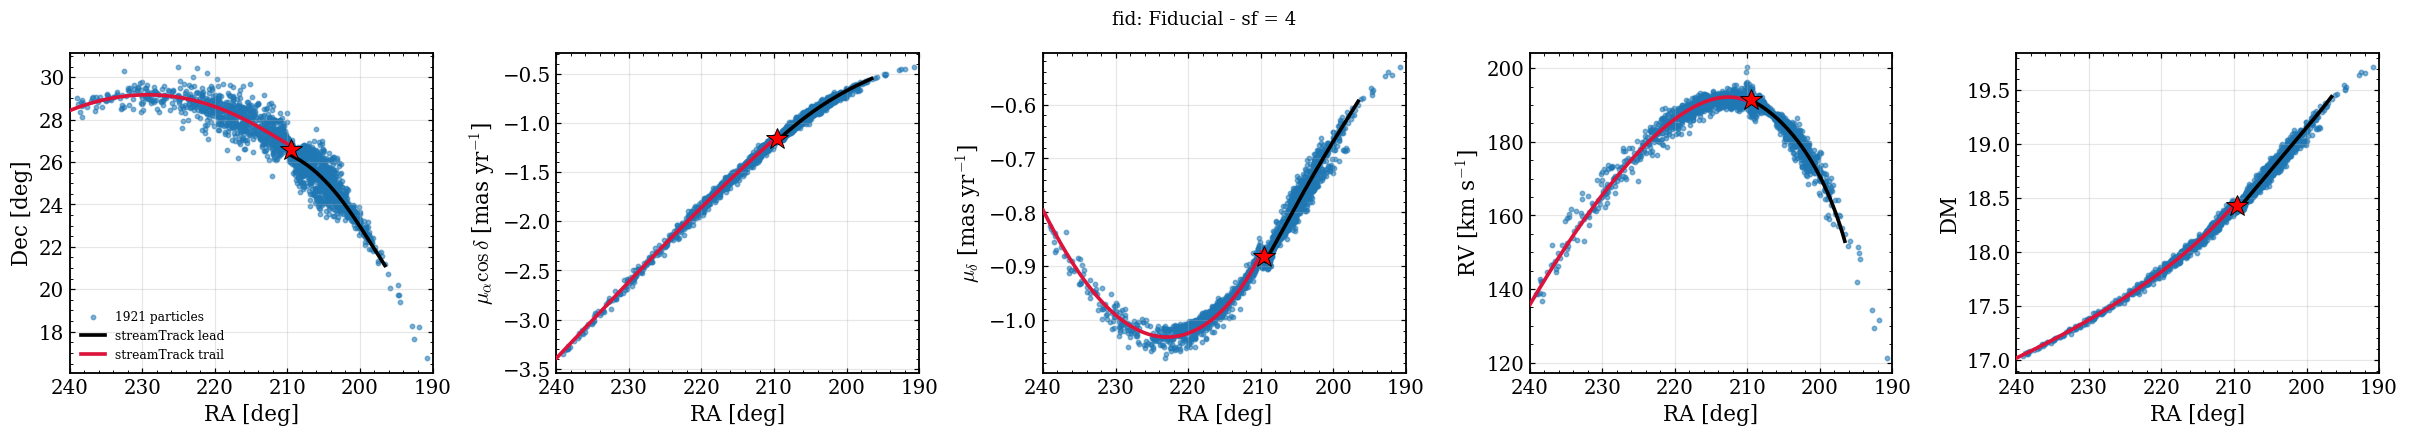

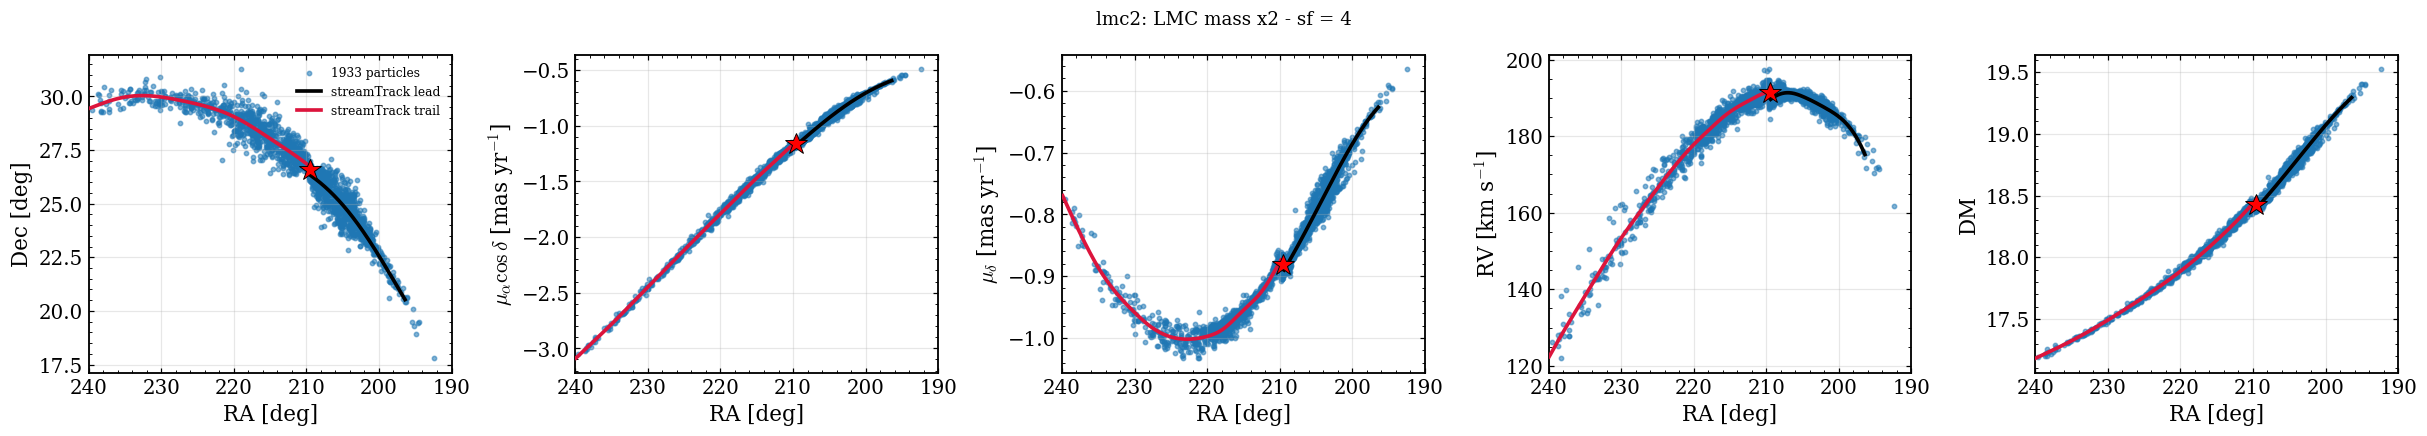

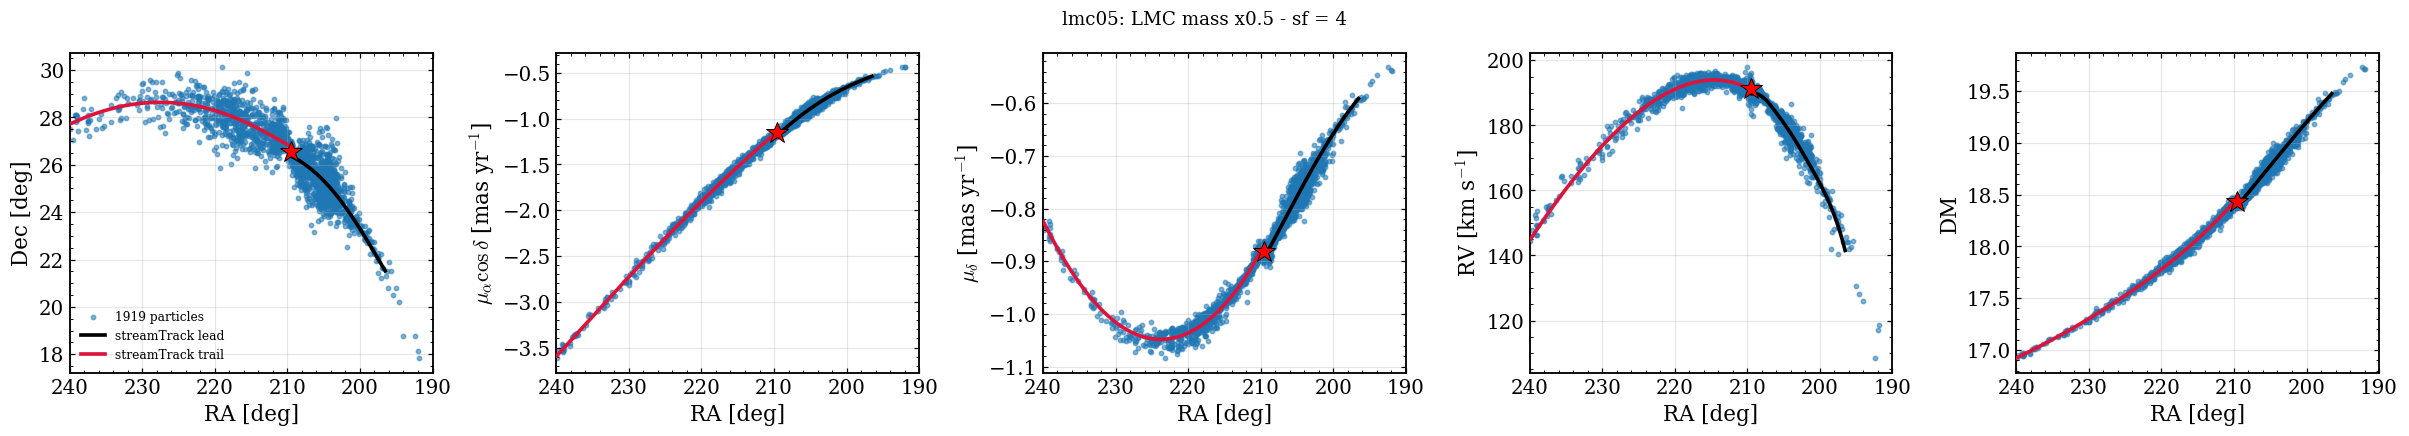

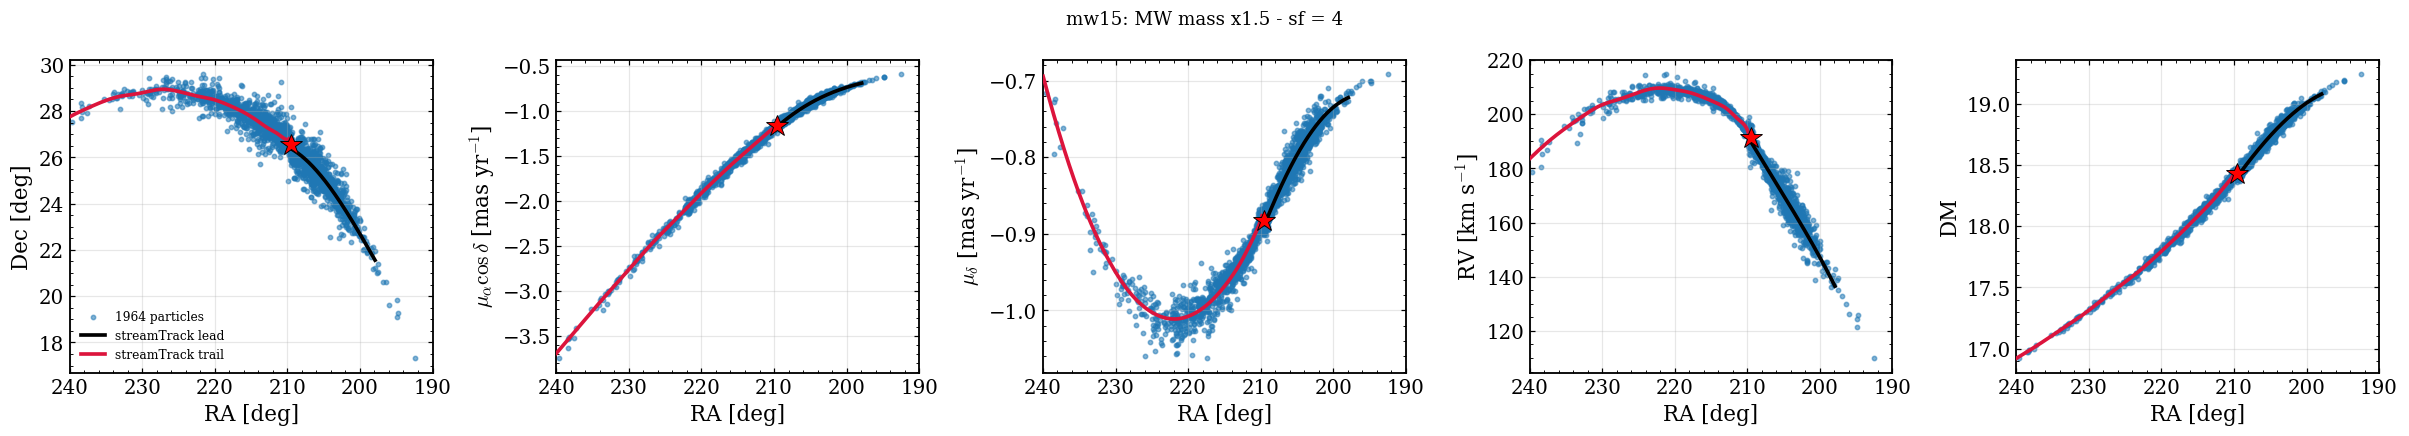

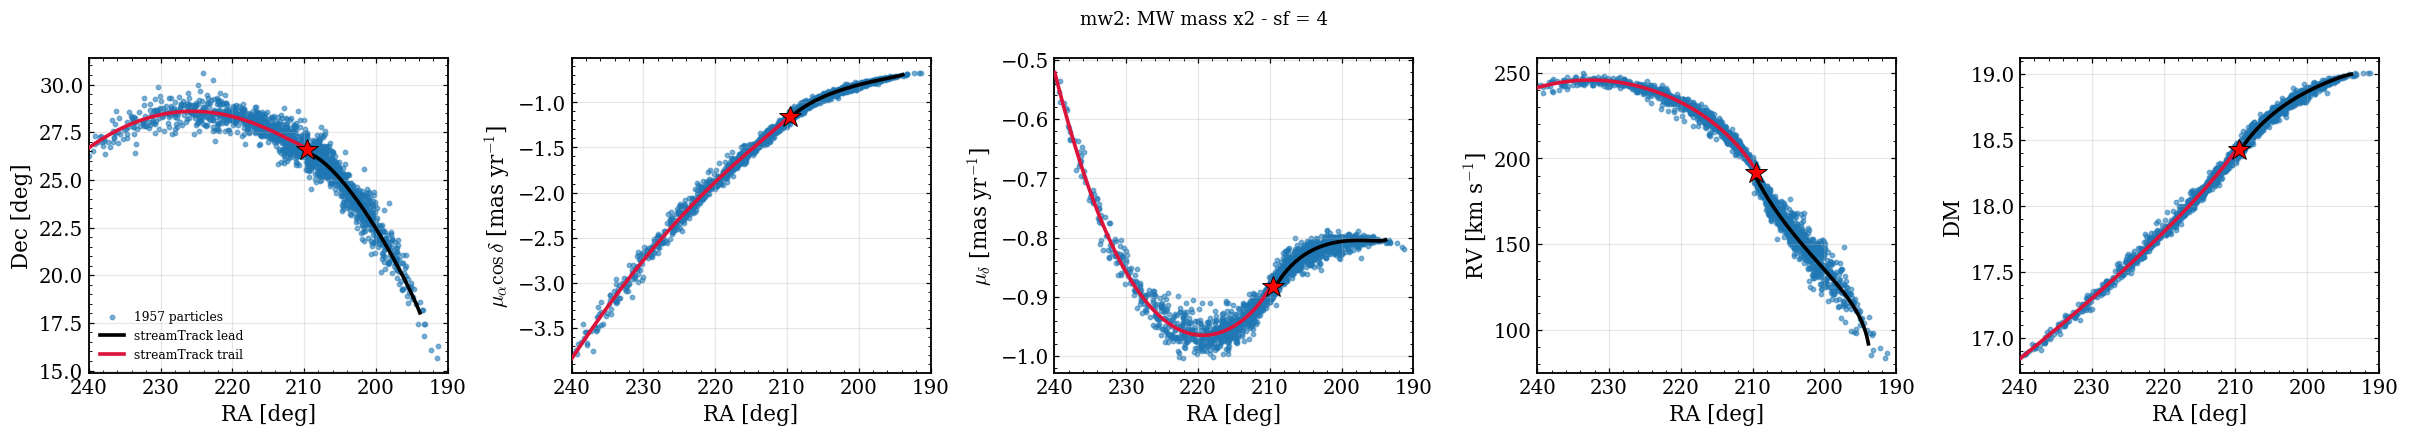

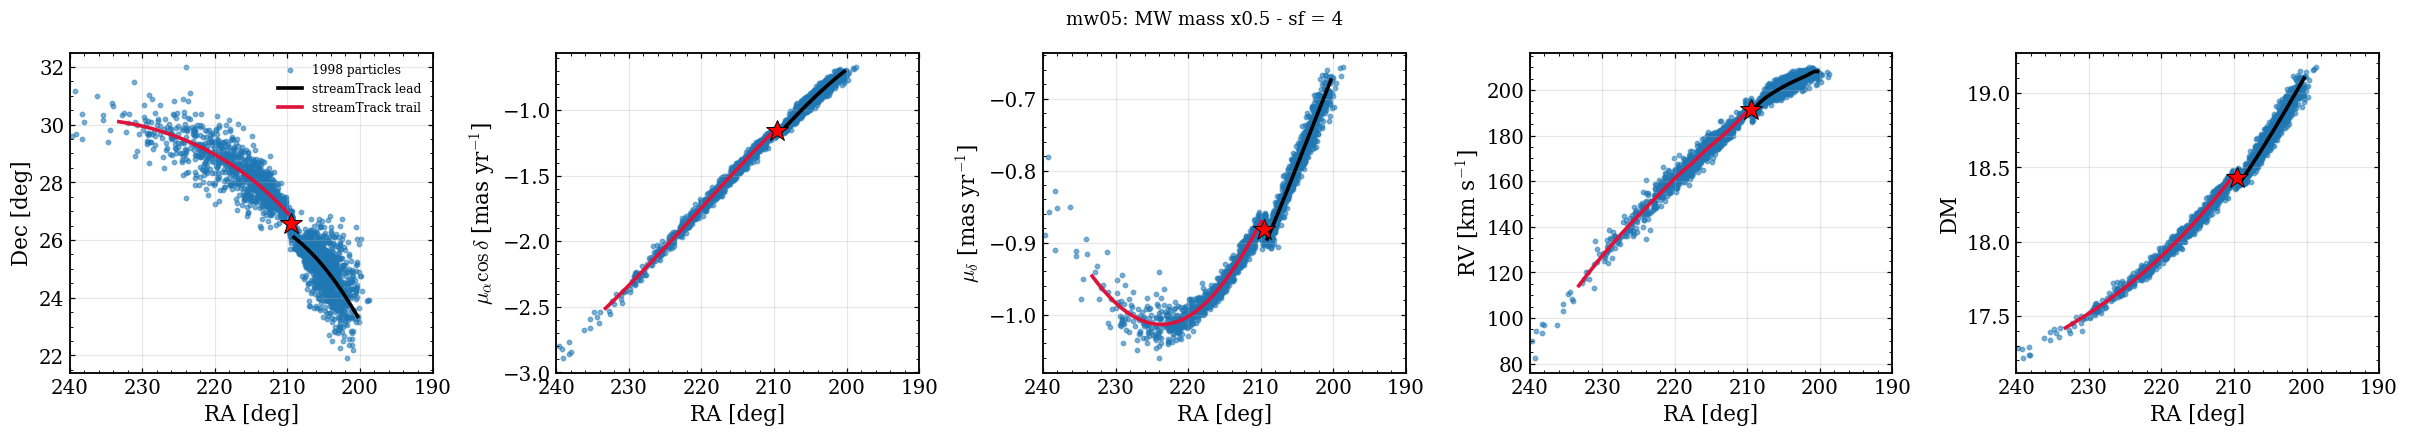

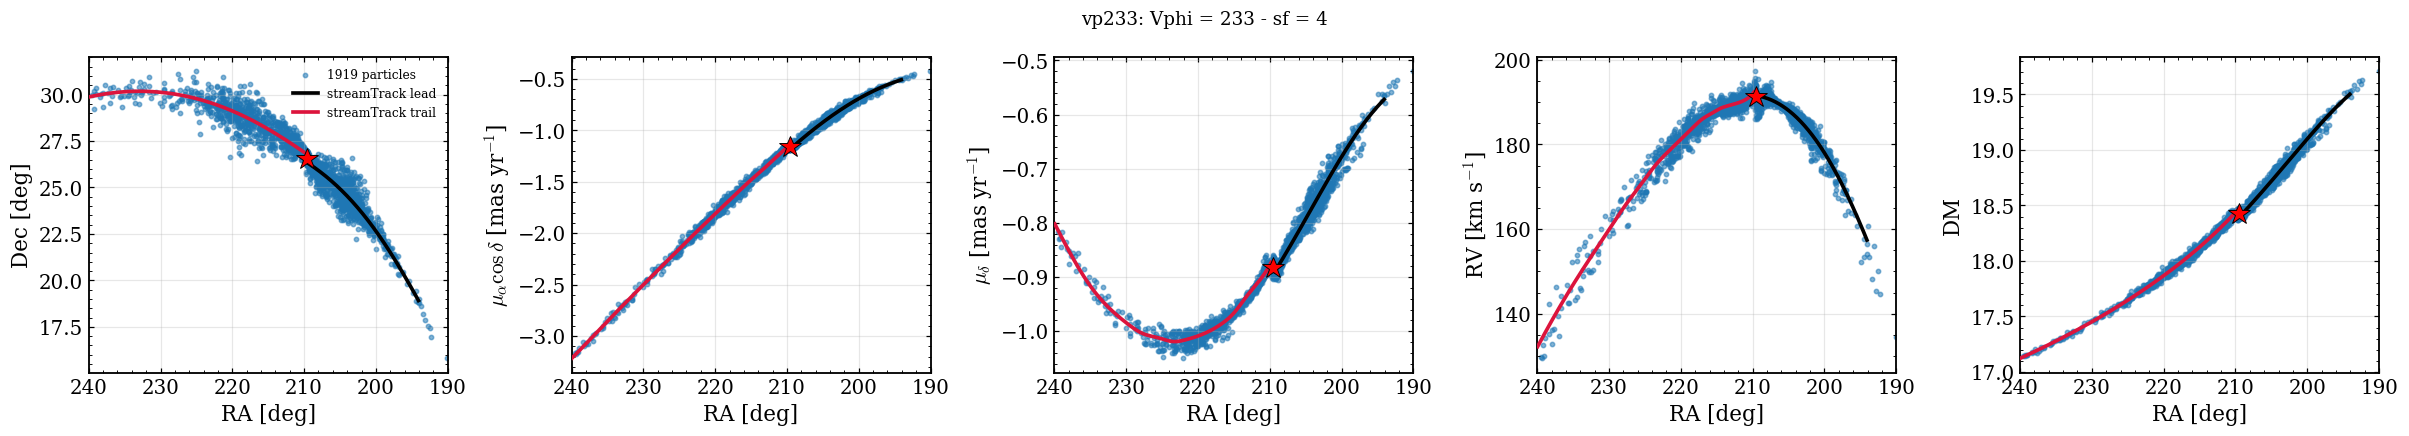

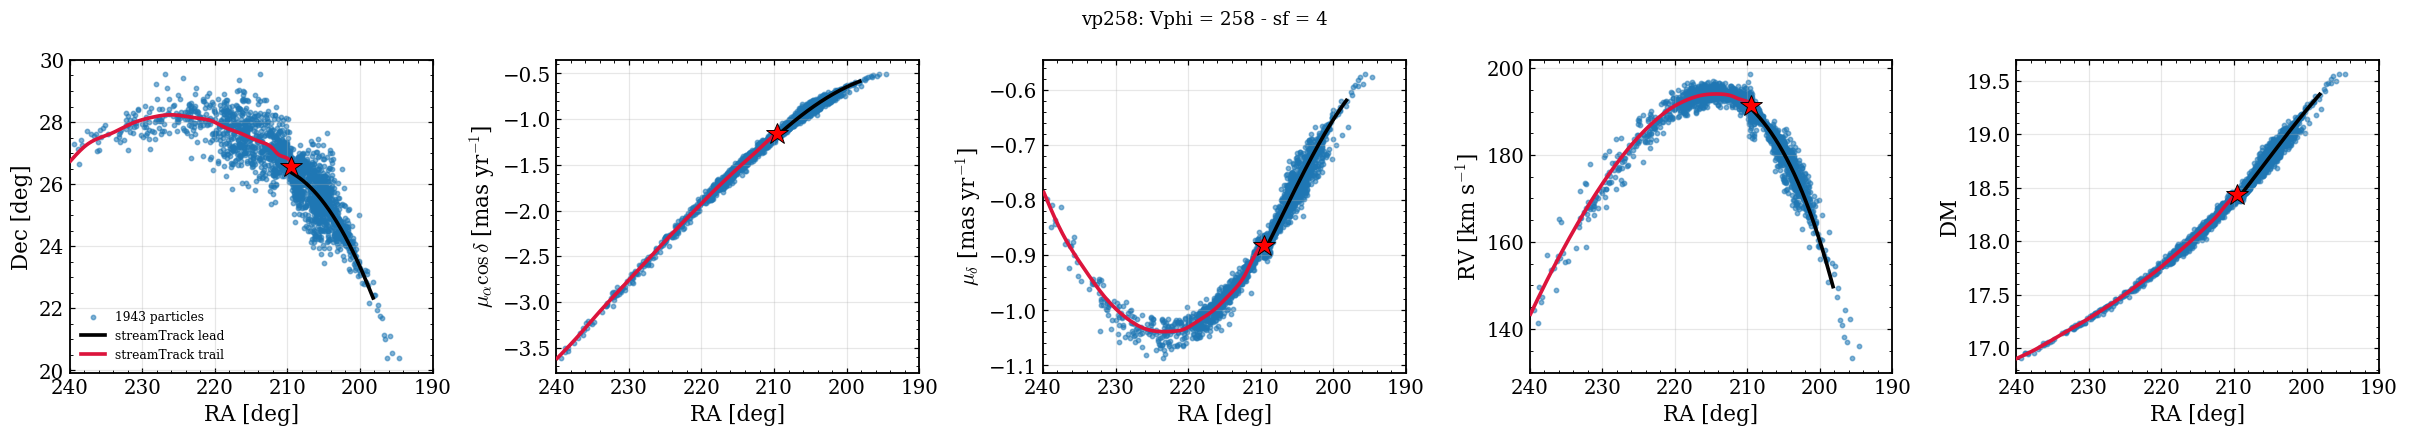

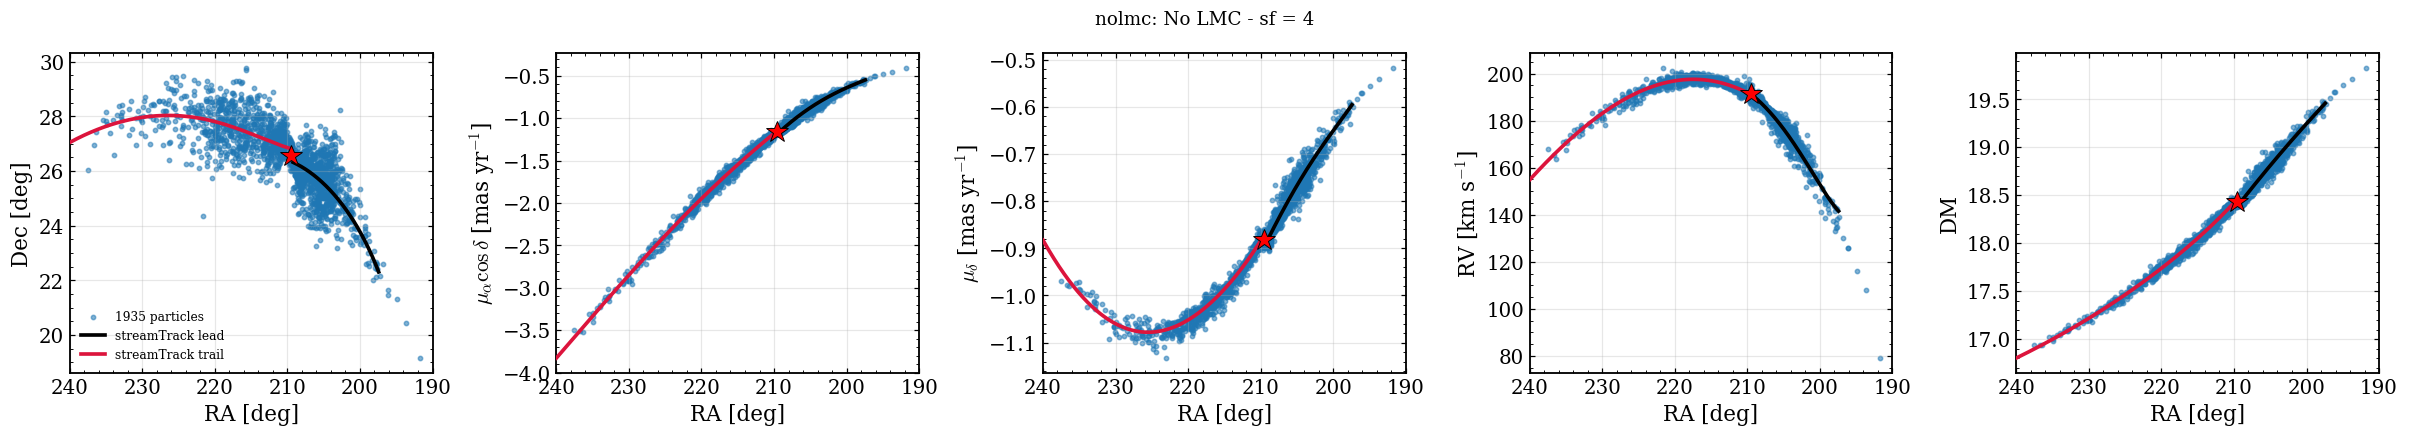

In [9]:
ROW_DEFS = [
    ("dec",   "Dec [deg]",                      DEC_BOO3),
    ("pmra",  r"$\mu_\alpha\cos\delta$ [mas yr$^{-1}$]",  pmra_med),
    ("pmdec", r"$\mu_\delta$ [mas yr$^{-1}$]",  pmdec_med),
    ("vlos",  r"RV [km s$^{-1}$]",              vhel_med),
    ("dm",    "DM",                              dm(DIST_KPC)),
]
PER_VARIATION_XLIM = (240, 190)


def _contiguous_in_window(arm, xlo, xhi):
    # Mask the contiguous tp_grid run that contains the progenitor (tp=0).
    # Suppresses wrap-around re-entries for heavy-MW potentials.
    tp = arm["tp"]; ra = arm["ra"]
    in_win = (ra >= xlo) & (ra <= xhi)
    if not in_win.any():
        return np.zeros_like(in_win)
    i0 = int(np.argmin(np.abs(tp)))
    if not in_win[i0]:
        idx = np.flatnonzero(np.diff(np.concatenate([[0], in_win.astype(int), [0]])))
        runs = idx.reshape(-1, 2)
        if runs.size == 0:
            return np.zeros_like(in_win)
        lens = runs[:, 1] - runs[:, 0]
        s, e = runs[np.argmax(lens)]
        m = np.zeros_like(in_win); m[s:e] = True
        return m
    i_lo = i0
    while i_lo > 0 and in_win[i_lo - 1]:
        i_lo -= 1
    i_hi = i0
    while i_hi < len(tp) - 1 and in_win[i_hi + 1]:
        i_hi += 1
    m = np.zeros_like(in_win)
    m[i_lo:i_hi + 1] = True
    return m


def show_per_variation(key, xlim=PER_VARIATION_XLIM):
    res = RESULTS[key]
    p, L, T = res["particles"], res["L"], res["T"]
    xlo, xhi = min(xlim), max(xlim)
    p_mask = (p["ra"] >= xlo) & (p["ra"] <= xhi)
    Lm = _contiguous_in_window(L, xlo, xhi)
    Tm = _contiguous_in_window(T, xlo, xhi)

    fig, axs = plt.subplots(1, 5, figsize=(22, 4))
    for ci, (rk, rlbl, pcen) in enumerate(ROW_DEFS):
        ax = axs[ci]
        py = p[rk]
        ax.scatter(p["ra"][p_mask], py[p_mask], s=8, c="tab:blue", alpha=0.55,
                   zorder=1, label=f"{p_mask.sum()} particles" if ci == 0 else None)
        ax.plot(L["ra"][Lm], L[rk][Lm], "-", c="black",   lw=2.4, zorder=3,
                label="streamTrack lead"  if ci == 0 else None)
        ax.plot(T["ra"][Tm], T[rk][Tm], "-", c="crimson", lw=2.4, zorder=3,
                label="streamTrack trail" if ci == 0 else None)
        ax.plot(RA_BOO3, pcen, "*", c="red", ms=15, mec="k", mew=0.6, zorder=10)
        ys = np.concatenate([py[p_mask], L[rk][Lm], T[rk][Tm]])
        ys = ys[np.isfinite(ys)]
        if ys.size > 0:
            ymin, ymax = ys.min(), ys.max()
            yspan = ymax - ymin
            ypad = 0.05 * yspan if yspan > 0 else 0.5
            ax.set_ylim(ymin - ypad, ymax + ypad)
        ax.set_xlim(*xlim)
        ax.set_xlabel("RA [deg]"); ax.set_ylabel(rlbl)
        ax.grid(alpha=0.3)
        if ci == 0:
            ax.legend(loc="best", fontsize=8)
    fig.suptitle(f"{key}: {res['label']} - sf = {res['smoothing_factor']:g}",
                 fontsize=12)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


for key in KEYS:
    show_per_variation(key)


## 9 · Figure 5 — master 5 x 4 grid

Rows = 5 observables (Dec, $\mu_\alpha\cos\delta$, $\mu_\delta$, RV, DM).
Columns = 4 variation groups (Fiducial; MW mass; LMC mass; $V_\phi$).

Each cell shows all variations belonging to that group, stacked: every
variation contributes its leading + trailing streamTrack curve, coloured
per the variation table above. The fiducial particle scatter is overlaid
in column 0 only.


In [ ]:
MASTER_XLIM = (230, 203)

# Styx stream track from Grillmair+2009 (priv. comm.) -- comparison overlay
# in the Dec row of the master grid only.
_styx_path = DATA_DIR / "styx.trace"
STYX_RA, STYX_DEC = np.loadtxt(_styx_path, unpack=True)

# --- Fiducial Boo III orbit (integrated +/- 0.5 Gyr in McMillan17+LMC) ---
# Overlaid as a black dashed line in the Fiducial column of the master grid,
# alongside the spray streamTrack curves.  Same potential as RESULTS["fid"].
from galpy.orbit import Orbit
from galpy.util.conversion import get_physical
def _compute_fid_orbit():
    pot_fid, _rtpot = build_lmc_potential(1.0, 1.0, SOLAR_MOTION_FID, True)
    phys = get_physical(_McMillan17_base); ro, vo = phys["ro"], phys["vo"]
    ts_b = -np.linspace(0, 0.5, 501) * u.Gyr
    ts_f =  np.linspace(0, 0.5, 501) * u.Gyr
    # 5-RRL distance d=48.47 kpc; see Section~4.
    PARAMS_6D_FIG5 = list(PARAMS_6D)  # use current 6D (d=48.47, post-rerun)
    o_b = Orbit(PARAMS_6D_FIG5, radec=True, solarmotion=SOLAR_MOTION_FID, ro=ro, vo=vo)
    o_f = Orbit(PARAMS_6D_FIG5, radec=True, solarmotion=SOLAR_MOTION_FID, ro=ro, vo=vo)
    o_b.integrate(ts_b, pot_fid); o_f.integrate(ts_f, pot_fid)
    out = dict(
        ra   = np.concatenate([np.asarray(o_b.ra(ts_b))[::-1],   np.asarray(o_f.ra(ts_f))]),
        dec  = np.concatenate([np.asarray(o_b.dec(ts_b))[::-1],  np.asarray(o_f.dec(ts_f))]),
        pmra = np.concatenate([np.asarray(o_b.pmra(ts_b))[::-1], np.asarray(o_f.pmra(ts_f))]),
        pmdec= np.concatenate([np.asarray(o_b.pmdec(ts_b))[::-1],np.asarray(o_f.pmdec(ts_f))]),
        vlos = np.concatenate([np.asarray(o_b.vlos(ts_b))[::-1], np.asarray(o_f.vlos(ts_f))]),
        dist = np.concatenate([np.asarray(o_b.dist(ts_b))[::-1], np.asarray(o_f.dist(ts_f))]),
    )
    out["dm"] = dm(out["dist"])
    return out
FID_ORBIT = _compute_fid_orbit()
print(f"Fid orbit integrated: RA {FID_ORBIT['ra'].min():.2f} -- {FID_ORBIT['ra'].max():.2f}")


def make_master_grid(sf=SMOOTHING_FACTOR, results=None, save_pdf=True):
    if results is None:
        results = RESULTS
    nrows = len(ROW_DEFS)
    ncols = len(GROUPS)
    fig, axs = plt.subplots(nrows, ncols, sharex=True, sharey="row",
                            figsize=(5.2 * ncols, 3.6 * nrows))
    fig.subplots_adjust(hspace=0.04, wspace=0.06)

    xlo, xhi = min(MASTER_XLIM), max(MASTER_XLIM)
    p_fid      = results["fid"]["particles"]
    p_fid_mask = (p_fid["ra"] >= xlo) & (p_fid["ra"] <= xhi)

    arm_masks = {k: (_contiguous_in_window(results[k]["L"], xlo, xhi),
                     _contiguous_in_window(results[k]["T"], xlo, xhi))
                 for k in KEYS}

    # Pass 1: gather y-range per row across all groups for shared ylim
    row_ylim = {}
    for ri, (rk, rlbl, pcen) in enumerate(ROW_DEFS):
        ys = []
        ys.append(p_fid[rk][p_fid_mask])
        for _, group_keys in GROUPS:
            for k in group_keys:
                Lm, Tm = arm_masks[k]
                ys.append(results[k]["L"][rk][Lm])
                ys.append(results[k]["T"][rk][Tm])
        ys.append(np.array([pcen]))
        if rk == "dec":
            sm = (STYX_RA >= xlo) & (STYX_RA <= xhi)
            ys.append(STYX_DEC[sm])
        ys = np.concatenate([np.atleast_1d(a) for a in ys])
        ys = ys[np.isfinite(ys)]
        if ys.size > 0:
            ymin, ymax = ys.min(), ys.max()
            yspan = ymax - ymin
            ypad = 0.05 * yspan if yspan > 0 else 0.5
            row_ylim[ri] = (ymin - ypad, ymax + ypad)

    # Pass 2: actually plot
    for ri, (rk, rlbl, pcen) in enumerate(ROW_DEFS):
        for ci, (group_name, group_keys) in enumerate(GROUPS):
            ax = axs[ri, ci]
            # Fiducial particles only on the leftmost column
            if ci == 0:
                ax.scatter(p_fid["ra"][p_fid_mask], p_fid[rk][p_fid_mask],
                           s=6, c="tab:blue", alpha=0.35, zorder=1,
                           label="fid particles" if ri == 0 else None)
            # Tracks: one per variation in this group
            for k in group_keys:
                Lm, Tm = arm_masks[k]
                col = results[k]["color"]
                lab = results[k]["label"] if ri == 0 else None
                ax.plot(results[k]["L"]["ra"][Lm],
                        results[k]["L"][rk][Lm], "-", c=col, lw=1.8,
                        alpha=0.95, label=lab, zorder=3)
                ax.plot(results[k]["T"]["ra"][Tm],
                        results[k]["T"][rk][Tm], "-", c=col, lw=1.8,
                        alpha=0.95, zorder=3)
            # Fiducial progenitor orbit overlay (Fiducial column only),
            # for visual comparison with the spray streamTrack curves
            # (linked to the dashed lines in Figure 8).
            if ci == 0:
                ra_o = FID_ORBIT["ra"]; y_o = FID_ORBIT[rk]
                m_o  = (ra_o >= xlo) & (ra_o <= xhi)
                ax.plot(ra_o[m_o], y_o[m_o], "k--", lw=1.2, alpha=0.8,
                        zorder=4,
                        label="Progenitor orbit (dashed)" if ri == 0 else None)
            # Styx track overlay — Dec row only, all columns
            if rk == "dec":
                ax.plot(STYX_RA, STYX_DEC, "k--", lw=1.8, alpha=0.7, zorder=5,
                        label="Styx (Grillmair+09)" if ri == 0 else None)
            # Centre marker(s). Particles + tracks already use the NEW 6D, so
            # every panel shows the NEW centroid; the OLD (Grillmair+09)
            # literature centre is overlaid only in the top-left panel as a
            # one-time direct comparison.
            is_top_left = (ri == 0 and ci == 0)
            ax.plot(RA_BOO3, pcen, "P", c="blue", ms=12, mec="k", mew=0.6, zorder=10,
                    label=(f"Boo III centre (this work, {RA_BOO3:.3f}, {DEC_BOO3:.3f})"
                           if is_top_left else None))
            if is_top_left:
                ax.plot(RA_OLD_BOO3, DEC_OLD_BOO3, "*", c="red", ms=14,
                        mec="k", mew=0.6, zorder=10,
                        label=f"Boo III centre (Grillmair+09, {RA_OLD_BOO3:.2f}, {DEC_OLD_BOO3:.2f})")
            ax.grid(alpha=0.3)
            ax.set_xlim(*MASTER_XLIM)
            if ri in row_ylim:
                ax.set_ylim(*row_ylim[ri])
            if ri == 0:
                ax.set_title(group_name, fontsize=15)
                ax.legend(loc="lower left", fontsize=11, framealpha=0.85)
            if ri == nrows - 1:
                ax.set_xlabel("RA [deg]")
            if ci == 0:
                ax.set_ylabel(rlbl)
    fig.tight_layout()
    if save_pdf:
        # Only save the canonical filename used by main.tex; the sf=4 grid is
        # the paper version, so any other sf invocation would clobber it ---
        # in practice we only call make_master_grid(sf=4).
        canonical = FIG_DIR / "fig5_streamtrack_grid.pdf"
        fig.savefig(canonical, dpi=200, bbox_inches="tight")
        print(f"Saved {canonical}")
    plt.show()
    plt.close(fig)


# sf = 4 grid (uses RESULTS computed in §7 above)
make_master_grid(sf=SMOOTHING_FACTOR)


---

**Outputs of this notebook**

| file | content |
|:--|:--|
| `output/spray_cache_new6D/spray_<key>.pkl`        | per-variation spray pkl (reproducible via fixed seed) |
| `figures/fig5_streamtrack_grid_sf4.pdf`     | Figure 5 candidate — sf=4 streamTrack grid (with Styx overlay in Dec row) |
| `figures/fig5_streamtrack_grid_sf20.pdf`    | Figure 5 candidate — sf=20 streamTrack grid (smoother) |

Pick whichever sf you want for the paper and either rename to
`fig5_streamtrack_grid.pdf` or update the figure include in the LaTeX.

**Re-rendering at a different `SMOOTHING_FACTOR`** is fast: rerun §7 with
the new sf, then §9 — the spray pkls are unchanged, only the streamTrack
splines get rebuilt.
